In [1]:
print('Hello world')
import pandas as pd

Hello world


In [2]:
#load data
df = pd.read_csv("GlobalLandTemperaturesByCity.csv", engine='pyarrow')


In [3]:
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


In [4]:
japan_df = df.loc[df['Country'] == 'Japan']
japan_df

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
45530,1845-01-01,2.377,2.006,Abiko,Japan,36.17N,139.23E
45531,1845-02-01,1.312,2.968,Abiko,Japan,36.17N,139.23E
45532,1845-03-01,5.276,1.506,Abiko,Japan,36.17N,139.23E
45533,1845-04-01,10.387,1.508,Abiko,Japan,36.17N,139.23E
45534,1845-05-01,14.923,1.448,Abiko,Japan,36.17N,139.23E
...,...,...,...,...,...,...,...
8480047,2013-05-01,16.757,0.396,Zama,Japan,36.17N,139.23E
8480048,2013-06-01,20.927,0.489,Zama,Japan,36.17N,139.23E
8480049,2013-07-01,24.645,0.404,Zama,Japan,36.17N,139.23E
8480050,2013-08-01,26.364,0.461,Zama,Japan,36.17N,139.23E


In [5]:
#Removing Latitide and Longiture's last letter
japan_df['Latitude'] = japan_df['Latitude'].map(lambda x: x.rstrip('N'))
japan_df['Longitude'] = japan_df['Longitude'].map(lambda x: x.rstrip('E'))
#Type conversion
convert_dict = {'Latitude': float, 'Longitude': float}
japan_df = japan_df.astype(convert_dict)
japan_df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
45530,1845-01-01,2.377,2.006,Abiko,Japan,36.17,139.23
45531,1845-02-01,1.312,2.968,Abiko,Japan,36.17,139.23
45532,1845-03-01,5.276,1.506,Abiko,Japan,36.17,139.23
45533,1845-04-01,10.387,1.508,Abiko,Japan,36.17,139.23
45534,1845-05-01,14.923,1.448,Abiko,Japan,36.17,139.23


In [6]:
import matplotlib.pyplot as plt
import geopandas as gpd

In [7]:
toudoufuken = gpd.read_file('jp.json')

In [8]:
leg_kwds = {
    'title':'Prefectures',
    'loc': 'upper right',
    'bbox_to_anchor':(2.28, 1.03),
    'ncol': 4
}

In [ ]:
#creating a point geometry
japan_df['geometry'] = gpd.points_from_xy(japan_df['Longitude'], japan_df['Latitude'])

In [12]:
japan_df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,geometry
45530,1845-01-01,2.377,2.006,Abiko,Japan,36.17,139.23,POINT (139.23 36.17)
45531,1845-02-01,1.312,2.968,Abiko,Japan,36.17,139.23,POINT (139.23 36.17)
45532,1845-03-01,5.276,1.506,Abiko,Japan,36.17,139.23,POINT (139.23 36.17)
45533,1845-04-01,10.387,1.508,Abiko,Japan,36.17,139.23,POINT (139.23 36.17)
45534,1845-05-01,14.923,1.448,Abiko,Japan,36.17,139.23,POINT (139.23 36.17)


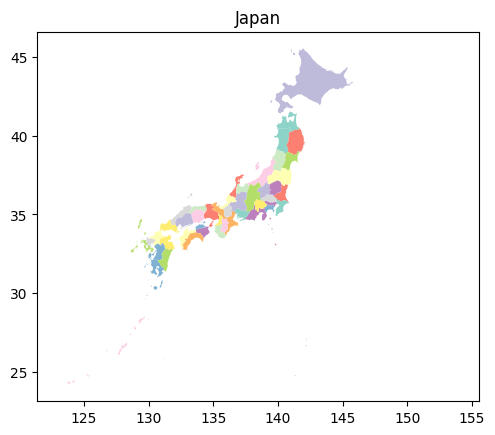

<Figure size 6000x7800 with 0 Axes>

In [ ]:
toudoufuken.plot(column='name', cmap='Set3', legend=False, legend_kwds=leg_kwds)
plt.title('Japan')
plt.figure(figsize=(20,26), dpi=300)
plt.show()